Valerie Jimenez and Nick Garcia
Lab 6 Decision Tree
https://www.kaggle.com/datasets/ohinhaque/ocd-patient-dataset-demographics-and-clinical-data

In [2]:
#Imported all necessary libraries for this algorithm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

In [3]:
from google.colab import files #imported our OCD dataset into the google colab notebook
uploaded=files.upload()
df=pd.read_csv('ocd.csv')
df

Saving ocd.csv to ocd.csv


,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,5374,38,Male,Hispanic,Divorced,College Degree,2019-01-10,53,MDD,No,Contamination,Washing,21,33,Yes,Yes,SSRI
1496,5013,19,Female,Hispanic,Divorced,Graduate Degree,2022-09-14,160,GAD,Yes,Hoarding,Praying,25,16,Yes,Yes,SSRI
1497,6089,40,Male,Asian,Married,Some College,2018-03-13,100,NaN,Yes,Contamination,Counting,2,15,Yes,Yes,Benzodiazepine
1498,3808,37,Female,Caucasian,Married,Some College,2018-04-14,210,GAD,Yes,Contamination,Washing,16,7,Yes,No,Benzodiazepine


In [4]:
df.isnull().sum() #this will check if there are any null values

,0
Patient ID,0
Age,0
Gender,0
Ethnicity,0
Marital Status,0
Education Level,0
OCD Diagnosis Date,0
Duration of Symptoms (months),0
Previous Diagnoses,248
Family History of OCD,0


In [5]:
df.dropna(inplace=True) #This will drop all null values from the columns
df.isnull().sum()#double checking for any null values

,0
Patient ID,0
Age,0
Gender,0
Ethnicity,0
Marital Status,0
Education Level,0
OCD Diagnosis Date,0
Duration of Symptoms (months),0
Previous Diagnoses,0
Family History of OCD,0


In [6]:
df.columns #displaying all columns so we can check which columns are needed

Index(['Patient ID', 'Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level', 'OCD Diagnosis Date',
       'Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Anxiety Diagnosis', 'Medications'],
      dtype='object')

In [7]:
#We decided to drop these two columns from our dataset
df.drop(columns=['OCD Diagnosis Date', 'Patient ID'], inplace=True)
df.head()

,Age,Gender,Ethnicity,Marital Status,Education Level,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,32,Female,African,Single,Some College,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
2,57,Male,Hispanic,Divorced,College Degree,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,27,Female,Hispanic,Married,College Degree,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
5,32,Female,Asian,Married,College Degree,46,GAD,No,Hoarding,Ordering,26,11,Yes,Yes,SSRI
6,38,Female,Hispanic,Single,College Degree,110,MDD,No,Contamination,Praying,12,16,Yes,No,SNRI


In [8]:
le=LabelEncoder() #Most of the columns were strings so made them into integers
#This will make it easier for the user to inputt numbers instead of strings when making a predictions
df['Gender']=le.fit_transform(df['Gender'])
df['Ethnicity']=le.fit_transform(df['Ethnicity'])
df['Marital Status']=le.fit_transform(df['Marital Status'])
df['Education Level']=le.fit_transform(df['Education Level'])
df['Previous Diagnoses']=le.fit_transform(df['Previous Diagnoses'])
df['Family History of OCD']=le.fit_transform(df['Family History of OCD'])
df['Obsession Type']=le.fit_transform(df['Obsession Type'])
df['Compulsion Type']=le.fit_transform(df['Compulsion Type'])
df['Depression Diagnosis']=le.fit_transform(df['Depression Diagnosis'])
df['Anxiety Diagnosis']=le.fit_transform(df['Anxiety Diagnosis'])
df['Medications']=le.fit_transform(df['Medications'])
df

,Age,Gender,Ethnicity,Marital Status,Education Level,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,32,0,0,2,3,203,1,0,1,0,17,10,1,1,1
2,57,1,3,0,0,173,1,0,0,0,3,4,0,0,0
3,27,0,3,1,0,126,2,1,4,4,14,28,1,1,2
5,32,0,1,1,0,46,0,0,2,2,26,11,1,1,2
6,38,0,3,2,0,110,1,0,0,3,12,16,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1492,40,0,1,0,2,177,1,1,1,1,27,21,1,1,1
1494,72,1,3,0,1,238,1,1,4,4,14,25,0,1,1
1495,38,1,3,0,0,53,1,0,0,4,21,33,1,1,2
1496,19,0,3,0,1,160,0,1,2,3,25,16,1,1,2


In [9]:
#split dataset into features and target variable
x_data=df[['Age', 'Gender', 'Ethnicity', 'Marital Status',
       'Education Level','Duration of Symptoms (months)', 'Previous Diagnoses',
       'Family History of OCD', 'Obsession Type', 'Compulsion Type',
       'Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)',
       'Depression Diagnosis', 'Medications']]
y_data=df['Anxiety Diagnosis']

In [10]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

In [11]:
#Create Decision Tree Classifier
dt_model= DecisionTreeClassifier()

#Train Decision Tree Classifier
dt_model2= dt_model.fit(X_train, y_train)

#Predict the response for test dataset
y_pred= dt_model2.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.49280575539568344


In [12]:
#This will determine the precision, recall, and F1 accuracy and the percentages.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
#This will print the precentages and the averages of the decision tree
#The precision will determine how positively true these cases are
#The recall will determine cases are identifies correctly
#The f1 score combines both
print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.53      0.50      0.52       150
           1       0.45      0.48      0.47       128

    accuracy                           0.49       278
   macro avg       0.49      0.49      0.49       278
weighted avg       0.50      0.49      0.49       278

The precision of the model is 0.45.
The recall of the model is 0.48.
The F1-score of the model is 0.47.


In [13]:
def predict_OCD():
    while True:
        try: #The user will manually inputt age, gender, ethnicity etc. To determine of the patient has anxiety with OCD
           Age = int(input("Enter Age: "))
           Gender = int(input("Enter the Gender(0/1): "))
           Ethnicity = int(input("Enter the Ethnicity(0-3): "))
           MaritalStatus = int(input("Enter the Martial Status(0-3): "))
           EducationLevel = int(input("Enter education level (0-3): "))
           DurationofSymptomsmonths = int(input("Enter the number of months: "))
           PreviousDiagnoses = int(input("Enter previous diagnoses(0-2): "))
           FamilyHistoryofOCD = int(input("Enter family history(0-2): "))
           ObsessionType = int(input("Enter the obsession type(0-4): "))
           CompulsionType = int(input("Enter the compulsion type(0-4): "))
           YBOCSScoreObsessions = int(input("Enter the YBOCS score: "))
           YBOCSScoreCompulsions = int(input("Enter the YBOCS score: "))
           DepressionDiagnosis = int(input("Enter diagnosis number(0/1): "))
           Medications = int(input("Enter medication number(0-2)"))
#Restarts the prediction if the user puts a negative value
           if any(val < 0 for val in [Age, Gender, Ethnicity, MaritalStatus, EducationLevel, DurationofSymptomsmonths, PreviousDiagnoses, FamilyHistoryofOCD, ObsessionType, CompulsionType, YBOCSScoreObsessions, YBOCSScoreCompulsions, DepressionDiagnosis, Medications]):
              print("Error: Please enter non-negative values for all features.")
              continue
              #Makes a new dataframe with the split variables and target outcome
           new_ocd_data = pd.DataFrame([[Age, Gender, Ethnicity, MaritalStatus, EducationLevel, DurationofSymptomsmonths, PreviousDiagnoses, FamilyHistoryofOCD, ObsessionType, CompulsionType, YBOCSScoreObsessions, YBOCSScoreCompulsions, DepressionDiagnosis, Medications]],
                                      columns=[Age, Gender, Ethnicity, MaritalStatus, EducationLevel, DurationofSymptomsmonths, PreviousDiagnoses, FamilyHistoryofOCD, ObsessionType, CompulsionType, YBOCSScoreObsessions, YBOCSScoreCompulsions, DepressionDiagnosis, Medications])

           prediction = dt_model2.predict(new_ocd_data)[0] #starts the prediction

           if prediction ==1: #if the prediction equals one then the patient has anxiety with OCD
                print("Prediction: Patient is likely to have anxiety with OCD.")
           else: #if it is not 1 then the patient does not anxiety with OCD
                print("Prediction: Patient is likely not to have anxiety with OCD.")
#Gives the user another option to predict for another patient who has anxiety and ocd
           another_patient = input("Enter data fro another patient? (yes/no):")
           if another_patient.lower() != 'yes':
               break
        except ValueError:
            print("Invalid input. Please enter valid numerical values.")

predict_OCD()
#prints the final output


Enter Age: 25
Enter the Gender(0/1): 1
Enter the Ethnicity(0-3): 2
Enter the Martial Status(0-3): 3
Enter education level (0-3): 3
Enter the number of months: 25
Enter previous diagnoses(0-2): 2
Enter family history(0-2): 0
Enter the obsession type(0-4): 1
Enter the compulsion type(0-4): 1
Enter the YBOCS score: 17
Enter the YBOCS score: 4
Enter diagnosis number(0/1): 1
Enter medication number(0-2)2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Prediction: Patient is likely to have anxiety with OCD.
Enter data fro another patient? (yes/no):no


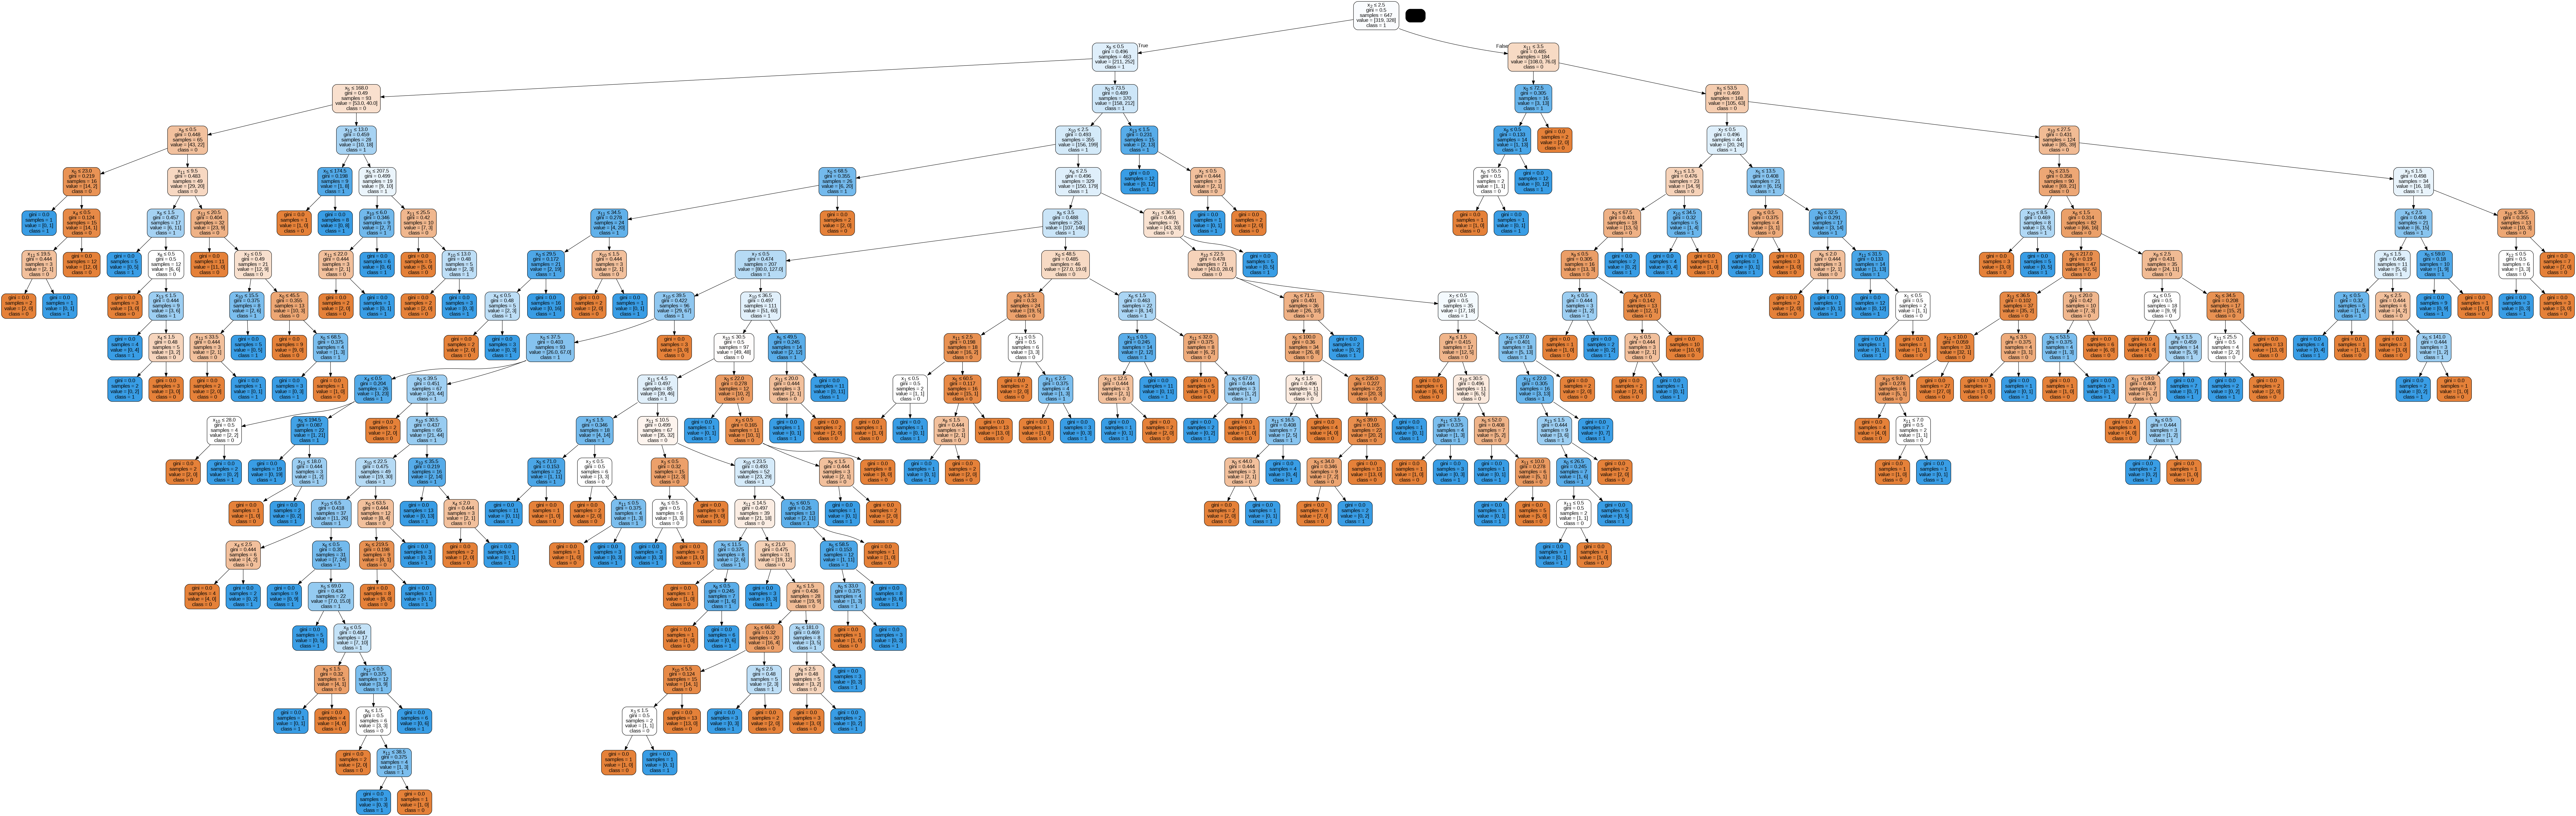

In [14]:
#These are new libraries to print out the decision tree and see all the nodes visually
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

# visualizing decison tree with max depth and min leaf nodes applied
dot_data = StringIO()
export_graphviz(dt_model2, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('ocd.png')
Image(graph.create_png())

In [15]:
#decision tree with pruning
dt_model3 = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
    min_samples_leaf=5, ccp_alpha=0.1, random_state=42)
dt_model4= dt_model3.fit(X_train, y_train)

#Predict the response for test dataset
y_pred= dt_model4.predict(X_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.460431654676259


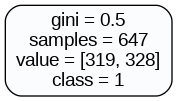

In [16]:
#This code will calculate all the calculations that were mentioned and explained.
dot_data = StringIO()
export_graphviz(dt_model4, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('ocd.png')
Image(graph.create_png())

We wanted to focus on the very first node to explain all the calculations within the node. The first calculation is the petal width which is 2.75. If it is great than 1.75, then you follow the false branch. The gini calulation determines how pure the level is of the dataset is and this node was 0.5.
The sample will just tell you how many sample it was fitted into the decision tree. The value is the distribution of the classes the algorithm it has identified. The class is the final outcome, this is where the node choses the final class based on most classes in the last calculation

*The* decision tree classification model was used on the OCD dataset to determine anxiety diagnoses based on demographic, clinical, and behavioral variables. Some data had to be converted from strings to numericals, and to reduce overfitting, cost-complexity pruning was applied using the ccp_alpha parameter, which removes branches. max_depth, min_samples_split, and min_samples_leaf were also adjusted to limit the complexity of the tree. Our accuracy was .53 and with pruning it went to .46.
